In [1]:
#TASK 1 - LOAD THE DATA
import numpy as np
from PIL import Image
import os

DATASET_PATH = "dataset"

In [2]:
# Names of 10 character classes

class_names = [
    "bart_simpson",
    "charles_montgomery_burns",
    "homer_simpson",
    "krusty_the_clown",
    "lisa_simpson",
    "marge_simpson",
    "milhouse_van_houten",
    "moe_szyslak",
    "ned_flanders",
    "principal_skinner"
]


In [3]:
def load_images(data_dir, image_mode):
    """Goes through each character folder + opens every image with Pillow,
    converts it to the given mode (grayscale or RGB), then flattens and
    scales it to [0, 1] so it's ready to use as input to the perceptron"""
    images = []
    labels = []
    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)

        for filename in sorted(os.listdir(class_dir)):
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                image_path = os.path.join(class_dir, filename)
                with Image.open(image_path) as image:
                    image = image.convert(image_mode)
                    image_array = np.asarray(image, dtype=np.float32).flatten() / 255.0
                images.append(image_array)
                labels.append(label)
    X = np.array(images)
    y = np.array(labels)
    return X, y

In [4]:
#Loadin grayscale training + test data
X_train_gray, y_train_gray = load_images(
    os.path.join(DATASET_PATH, "grayscale", "train"), "L"
)
X_test_gray, y_test_gray = load_images(
    os.path.join(DATASET_PATH, "grayscale", "test"), "L"
)

#Load RGB training and test data
X_train_rgb, y_train_rgb = load_images(
    os.path.join(DATASET_PATH, "rgb", "train"), "RGB"
)
X_test_rgb, y_test_rgb = load_images(
    os.path.join(DATASET_PATH, "rgb", "test"), "RGB"
)

In [5]:
# Splitin off a validation set from the training data
np.random.seed(1234)
valid_size = X_test_gray.shape[0]
indices = np.random.choice(X_train_gray.shape[0], valid_size, replace=False)

X_valid_gray = X_train_gray[indices]
y_valid_gray = y_train_gray[indices]
X_train_gray = np.delete(X_train_gray, indices, axis=0)
y_train_gray = np.delete(y_train_gray, indices, axis=0)

X_valid_rgb = X_train_rgb[indices]
y_valid_rgb = y_train_rgb[indices]
X_train_rgb = np.delete(X_train_rgb, indices, axis=0)
y_train_rgb = np.delete(y_train_rgb, indices, axis=0)


In [6]:
# Checking size of each dataset
print("Grayscale:", X_train_gray.shape, X_valid_gray.shape, X_test_gray.shape)
print("RGB:      ", X_train_rgb.shape, X_valid_rgb.shape, X_test_rgb.shape)

Grayscale: (6000, 784) (2000, 784) (2000, 784)
RGB:       (6000, 2352) (2000, 2352) (2000, 2352)


In [7]:
# TASK 2

class BinaryPerceptron:
 
    def __init__(self, n_inputs, alpha=0.01):
        self.weights = np.full(n_inputs, 0.1)
        self.bias = 0.1
        self.alpha = alpha
 
    def net_input(self, x):
        """Calculates the raw weighted sum of the inputs plus the bias"""
        return np.dot(x, self.weights) + self.bias
 
    def predict(self, x):
        """Turns the raw score into a binary prediction: 1 if it's 0 or above, otherwise 0"""
        return 1 if self.net_input(x) >= 0 else 0
 
    def apply_learning_rule(self, x, y):
        """Applying the perceptron update rule: comparing my prediction to the true label and only adjusting weights/bias when they differ"""
        g = self.predict(x)
        self.weights = self.weights + self.alpha * (y - g) * x
        self.bias = self.bias + self.alpha * (y - g)

In [8]:

def train(model, X_train, y_train, X_valid, y_valid, epochs=10):
    
  """Trains the given model for a fixed number of epochs, shuffling the
  training data each time, and prints validation accuracy after every epoch"""
    
    for epoch in range(epochs):
 
        # Shuffling the training data each epoch so I'm not feeding it examples in the same class-grouped order every time
        indices = np.random.permutation(len(X_train))
 
        for i in indices:
            model.apply_learning_rule(X_train[i], y_train[i])
 
        correct = 0
 
        for i in range(len(X_valid)):
            if model.predict(X_valid[i]) == y_valid[i]:
                correct += 1
 
        accuracy = correct / len(X_valid)
 
        print(f"Epoch {epoch + 1} - Validation accuracy: {accuracy:.2f}")

In [9]:
class MultiClassPerceptron:
 
    def __init__(self, n_inputs, n_classes=10, alpha=0.01):
        """Builds one BinaryPerceptron per class, so 10 in total for this dataset"""
        self.perceptrons = []
 
        for i in range(n_classes):
            self.perceptrons.append(
                BinaryPerceptron(n_inputs, alpha)
            )
 
    def predict(self, x):
        """Getting a raw score from each of the 10 perceptrons, then picking whichever class's perceptron is most confident"""
        scores = []
 
        for perceptron in self.perceptrons:
            scores.append(perceptron.net_input(x))
 
        return np.argmax(scores)
 
    def apply_learning_rule(self, x, y):
        """Converts the single true label into 10 binary targets (1 for
        the correct class, 0 for the rest) and updates all 10 perceptrons"""
 
        for class_index in range(10):
 
            # Turning the multi-class label into a binary target: 1 for the perceptron matching the true class, 0 for the rest
            if class_index == y:
                target = 1
            else:
                target = 0
 
            self.perceptrons[class_index].apply_learning_rule(
                x, target
            )
 

In [10]:
# TASK 3 
"""Tracking final validation accuracy for each config so I can compare them """
 #Grayscale: fixed-epoch runs across different learning rates

np.random.seed(1234)
p_gray = MultiClassPerceptron(
    n_inputs=X_train_gray.shape[1],
    n_classes=10,
    alpha=0.1
)

train(
    p_gray,
    X_train_gray,
    y_train_gray,
    X_valid_gray,
    y_valid_gray,
    epochs=20
)

Epoch 1 - Validation accuracy: 0.17
Epoch 2 - Validation accuracy: 0.14
Epoch 3 - Validation accuracy: 0.15
Epoch 4 - Validation accuracy: 0.22
Epoch 5 - Validation accuracy: 0.22
Epoch 6 - Validation accuracy: 0.23
Epoch 7 - Validation accuracy: 0.21
Epoch 8 - Validation accuracy: 0.15
Epoch 9 - Validation accuracy: 0.16
Epoch 10 - Validation accuracy: 0.20
Epoch 11 - Validation accuracy: 0.24
Epoch 12 - Validation accuracy: 0.20
Epoch 13 - Validation accuracy: 0.13
Epoch 14 - Validation accuracy: 0.15
Epoch 15 - Validation accuracy: 0.26
Epoch 16 - Validation accuracy: 0.23
Epoch 17 - Validation accuracy: 0.21
Epoch 18 - Validation accuracy: 0.16
Epoch 19 - Validation accuracy: 0.23
Epoch 20 - Validation accuracy: 0.21


In [11]:
np.random.seed(1234)
p_gray = MultiClassPerceptron(
    n_inputs=X_train_gray.shape[1],
    n_classes=10,
    alpha=0.01
)

train(
    p_gray,
    X_train_gray,
    y_train_gray,
    X_valid_gray,
    y_valid_gray,
    epochs=20
)


Epoch 1 - Validation accuracy: 0.14
Epoch 2 - Validation accuracy: 0.19
Epoch 3 - Validation accuracy: 0.15
Epoch 4 - Validation accuracy: 0.24
Epoch 5 - Validation accuracy: 0.13
Epoch 6 - Validation accuracy: 0.21
Epoch 7 - Validation accuracy: 0.20
Epoch 8 - Validation accuracy: 0.23
Epoch 9 - Validation accuracy: 0.19
Epoch 10 - Validation accuracy: 0.23
Epoch 11 - Validation accuracy: 0.21
Epoch 12 - Validation accuracy: 0.23
Epoch 13 - Validation accuracy: 0.17
Epoch 14 - Validation accuracy: 0.16
Epoch 15 - Validation accuracy: 0.20
Epoch 16 - Validation accuracy: 0.20
Epoch 17 - Validation accuracy: 0.22
Epoch 18 - Validation accuracy: 0.21
Epoch 19 - Validation accuracy: 0.16
Epoch 20 - Validation accuracy: 0.19


In [12]:
np.random.seed(1234)
p_gray = MultiClassPerceptron(
    n_inputs=X_train_gray.shape[1],
    n_classes=10,
    alpha=0.001
)

train(
    p_gray,
    X_train_gray,
    y_train_gray,
    X_valid_gray,
    y_valid_gray,
    epochs=20
)

Epoch 1 - Validation accuracy: 0.14
Epoch 2 - Validation accuracy: 0.14
Epoch 3 - Validation accuracy: 0.16
Epoch 4 - Validation accuracy: 0.22
Epoch 5 - Validation accuracy: 0.15
Epoch 6 - Validation accuracy: 0.20
Epoch 7 - Validation accuracy: 0.21
Epoch 8 - Validation accuracy: 0.22
Epoch 9 - Validation accuracy: 0.19
Epoch 10 - Validation accuracy: 0.21
Epoch 11 - Validation accuracy: 0.26
Epoch 12 - Validation accuracy: 0.18
Epoch 13 - Validation accuracy: 0.18
Epoch 14 - Validation accuracy: 0.19
Epoch 15 - Validation accuracy: 0.23
Epoch 16 - Validation accuracy: 0.24
Epoch 17 - Validation accuracy: 0.20
Epoch 18 - Validation accuracy: 0.24
Epoch 19 - Validation accuracy: 0.19
Epoch 20 - Validation accuracy: 0.17


In [13]:
#RGB: fixed-epoch runs across different learning rates 
np.random.seed(1234)
p_rgb = MultiClassPerceptron(
    n_inputs=X_train_rgb.shape[1],
    n_classes=10,
    alpha=0.1
)

train(
    p_rgb,
    X_train_rgb,
    y_train_rgb,
    X_valid_rgb,
    y_valid_rgb,
    epochs=20
)


Epoch 1 - Validation accuracy: 0.26
Epoch 2 - Validation accuracy: 0.22
Epoch 3 - Validation accuracy: 0.27
Epoch 4 - Validation accuracy: 0.36
Epoch 5 - Validation accuracy: 0.33
Epoch 6 - Validation accuracy: 0.35
Epoch 7 - Validation accuracy: 0.33
Epoch 8 - Validation accuracy: 0.33
Epoch 9 - Validation accuracy: 0.37
Epoch 10 - Validation accuracy: 0.26
Epoch 11 - Validation accuracy: 0.34
Epoch 12 - Validation accuracy: 0.38
Epoch 13 - Validation accuracy: 0.37
Epoch 14 - Validation accuracy: 0.36
Epoch 15 - Validation accuracy: 0.38
Epoch 16 - Validation accuracy: 0.37
Epoch 17 - Validation accuracy: 0.31
Epoch 18 - Validation accuracy: 0.33
Epoch 19 - Validation accuracy: 0.36
Epoch 20 - Validation accuracy: 0.37


In [14]:
np.random.seed(1234)
p_rgb = MultiClassPerceptron(
    n_inputs=X_train_rgb.shape[1],
    n_classes=10,
    alpha=0.01
)

train(
    p_rgb,
    X_train_rgb,
    y_train_rgb,
    X_valid_rgb,
    y_valid_rgb,
    epochs=20
)

Epoch 1 - Validation accuracy: 0.25
Epoch 2 - Validation accuracy: 0.35
Epoch 3 - Validation accuracy: 0.39
Epoch 4 - Validation accuracy: 0.36
Epoch 5 - Validation accuracy: 0.26
Epoch 6 - Validation accuracy: 0.31
Epoch 7 - Validation accuracy: 0.38
Epoch 8 - Validation accuracy: 0.33
Epoch 9 - Validation accuracy: 0.37
Epoch 10 - Validation accuracy: 0.36
Epoch 11 - Validation accuracy: 0.35
Epoch 12 - Validation accuracy: 0.40
Epoch 13 - Validation accuracy: 0.39
Epoch 14 - Validation accuracy: 0.35
Epoch 15 - Validation accuracy: 0.38
Epoch 16 - Validation accuracy: 0.42
Epoch 17 - Validation accuracy: 0.32
Epoch 18 - Validation accuracy: 0.27
Epoch 19 - Validation accuracy: 0.41
Epoch 20 - Validation accuracy: 0.33


In [15]:
np.random.seed(1234)
p_rgb = MultiClassPerceptron(
    n_inputs=X_train_rgb.shape[1],
    n_classes=10,
    alpha=0.001
)

train(
    p_rgb,
    X_train_rgb,
    y_train_rgb,
    X_valid_rgb,
    y_valid_rgb,
    epochs=20 
)

Epoch 1 - Validation accuracy: 0.21
Epoch 2 - Validation accuracy: 0.24
Epoch 3 - Validation accuracy: 0.30
Epoch 4 - Validation accuracy: 0.38
Epoch 5 - Validation accuracy: 0.29
Epoch 6 - Validation accuracy: 0.36
Epoch 7 - Validation accuracy: 0.32
Epoch 8 - Validation accuracy: 0.32
Epoch 9 - Validation accuracy: 0.32
Epoch 10 - Validation accuracy: 0.30
Epoch 11 - Validation accuracy: 0.34
Epoch 12 - Validation accuracy: 0.38
Epoch 13 - Validation accuracy: 0.43
Epoch 14 - Validation accuracy: 0.37
Epoch 15 - Validation accuracy: 0.39
Epoch 16 - Validation accuracy: 0.36
Epoch 17 - Validation accuracy: 0.36
Epoch 18 - Validation accuracy: 0.30
Epoch 19 - Validation accuracy: 0.36
Epoch 20 - Validation accuracy: 0.38


In [16]:
def train_early_stopping(model, X_train, y_train, X_valid, y_valid,
                          max_epochs=20, patience=3):
    
    """ Trains the model epoch by epoch like train(), but stops once
    validation accuracy hasn't improved for "patience" epochs in a row,
    and restores the weights from the best-performing epoch at the end"""
 
    best_accuracy = 0.0
    epochs_without_improvement = 0
    
    """Storing a copy of the weights/bias whenever validation accuracy improves, 
    so I can restore the best version instead of whatever the model looks like when training stops"""
    
    best_weights = [np.copy(p.weights) for p in model.perceptrons]
    best_biases = [p.bias for p in model.perceptrons]
 
    for epoch in range(max_epochs):
 
        indices = np.random.permutation(len(X_train))
 
        for i in indices:
            model.apply_learning_rule(X_train[i], y_train[i])
 
        correct = 0
        for i in range(len(X_valid)):
            if model.predict(X_valid[i]) == y_valid[i]:
                correct += 1
 
        accuracy = correct / len(X_valid)
 
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            epochs_without_improvement = 0
            best_weights = [np.copy(p.weights) for p in model.perceptrons]
            best_biases = [p.bias for p in model.perceptrons]
        else:
            epochs_without_improvement += 1
 
        if epochs_without_improvement >= patience:
            break
 
    # Restoring the model to its best-performing epoch
    for p, w, b in zip(model.perceptrons, best_weights, best_biases):
        p.weights = w
        p.bias = b
 
    return best_accuracy

In [17]:
# Creating a new grayscale multi-class perceptron with alpha=0.01 (learning rate that performed best in earlier sweep)
np.random.seed(1234)
results = {}
p_gray_early = MultiClassPerceptron(
    n_inputs=X_train_gray.shape[1],
    n_classes=10,
    alpha=0.01
)
 
results["gray_early_stop"] = train_early_stopping(
    p_gray_early,
    X_train_gray,
    y_train_gray,
    X_valid_gray,
    y_valid_gray,
    max_epochs=20,
    patience=3
)
 

In [18]:
# Same idea but for the RGB model, using alpha=0.1
np.random.seed(1234)
p_rgb_early = MultiClassPerceptron(
    n_inputs=X_train_rgb.shape[1],
    n_classes=10,
    alpha=0.1
)
 
results["rgb_early_stop"] = train_early_stopping(
    p_rgb_early,
    X_train_rgb,
    y_train_rgb,
    X_valid_rgb,
    y_valid_rgb,
    max_epochs=20,
    patience=3
)
 

In [19]:
# TASK 4

def normalize(X_train, X_other, method):
    """ Scales the pixel values using one of three methods (none, min-max,
    z-score), always using the training set's own stats so the same 
    transformation is applied consistently to the other set
    X_other is validation - use train's mean/std  """
    if method == "none":
        return X_train * 255.0, X_other * 255.0 
    elif method == "minmax":
        return X_train, X_other 
    elif method == "zscore":
        mean = X_train.mean()
        std = X_train.std()
        return (X_train - mean) / std, (X_other - mean) / std




In [20]:
# grid search - gray
learning_rates = [0.1, 0.01, 0.001]
norm_methods = ["none", "minmax", "zscore"]

results = {}      
histories = {}    

for alpha in learning_rates:
    for method in norm_methods:
        X_train_norm, X_valid_norm = normalize(X_train_gray, X_valid_gray, method)

        np.random.seed(1234)
        model = MultiClassPerceptron(n_inputs=X_train_norm.shape[1], n_classes=10, alpha=alpha)

        best_acc = 0
        acc_per_epoch = []

        for epoch in range(20):
            indices = np.random.permutation(len(X_train_norm))
            for i in indices:
                model.apply_learning_rule(X_train_norm[i], y_train_gray[i])

            correct = sum(model.predict(X_valid_norm[i]) == y_valid_gray[i] for i in range(len(X_valid_norm)))
            acc = correct / len(X_valid_norm)
            best_acc = max(best_acc, acc)
            acc_per_epoch.append(acc)  

        results[(alpha, method)] = best_acc
        histories[(alpha, method)] = acc_per_epoch
        print(f"alpha={alpha}, norm={method} -> best accuracy: {best_acc:.2f}")

results_gray = results
histories_gray = histories


alpha=0.1, norm=none -> best accuracy: 0.23
alpha=0.1, norm=minmax -> best accuracy: 0.26
alpha=0.1, norm=zscore -> best accuracy: 0.24
alpha=0.01, norm=none -> best accuracy: 0.21
alpha=0.01, norm=minmax -> best accuracy: 0.24
alpha=0.01, norm=zscore -> best accuracy: 0.25
alpha=0.001, norm=none -> best accuracy: 0.23
alpha=0.001, norm=minmax -> best accuracy: 0.26
alpha=0.001, norm=zscore -> best accuracy: 0.24


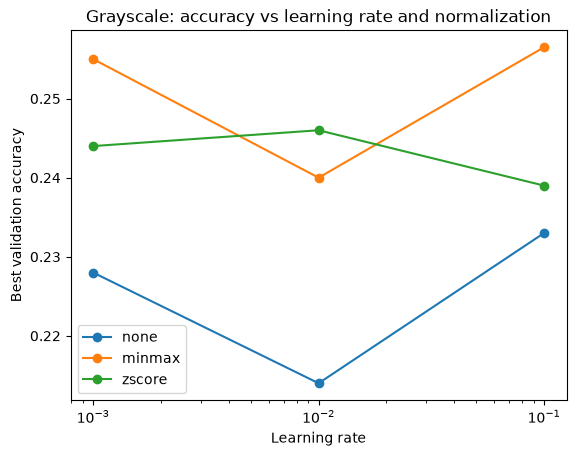

In [21]:
import matplotlib.pyplot as plt

for method in norm_methods:
    accs = [results_gray[(alpha, method)] for alpha in learning_rates]
    plt.plot(learning_rates, accs, marker='o', label=method)

plt.xscale('log')
plt.xlabel("Learning rate")
plt.ylabel("Best validation accuracy")
plt.title("Grayscale: accuracy vs learning rate and normalization")
plt.legend()
plt.show()

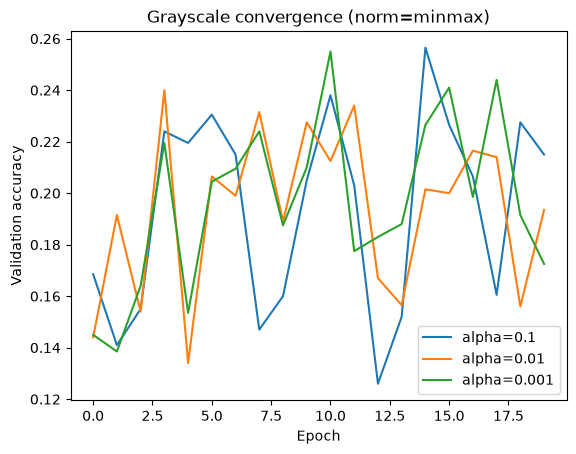

In [22]:
# convergence plot-accuracy per epoch for each learning rate
best_method_gray = "minmax"

for alpha in learning_rates:
    plt.plot(histories_gray[(alpha, best_method_gray)], label=f"alpha={alpha}")

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title(f"Grayscale convergence (norm={best_method_gray})")
plt.legend()
plt.show()

In [23]:
# grid search - RGB
results_rgb = {}
histories_rgb = {}

for alpha in learning_rates:
    for method in norm_methods:
        X_train_norm, X_valid_norm = normalize(X_train_rgb, X_valid_rgb, method)

        np.random.seed(1234)
        model = MultiClassPerceptron(n_inputs=X_train_norm.shape[1], n_classes=10, alpha=alpha)

        best_acc = 0
        acc_per_epoch = []

        for epoch in range(20):
            indices = np.random.permutation(len(X_train_rgb))
            for i in indices:
                model.apply_learning_rule(X_train_norm[i], y_train_rgb[i])

            correct = sum(model.predict(X_valid_norm[i]) == y_valid_rgb[i] for i in range(len(X_valid_norm)))
            acc = correct / len(X_valid_norm)
            best_acc = max(best_acc, acc)
            acc_per_epoch.append(acc)

        results_rgb[(alpha, method)] = best_acc
        histories_rgb[(alpha, method)] = acc_per_epoch
        print(f"alpha={alpha}, norm={method} -> best accuracy: {best_acc:.2f}")


alpha=0.1, norm=none -> best accuracy: 0.40
alpha=0.1, norm=minmax -> best accuracy: 0.38
alpha=0.1, norm=zscore -> best accuracy: 0.40
alpha=0.01, norm=none -> best accuracy: 0.41
alpha=0.01, norm=minmax -> best accuracy: 0.42
alpha=0.01, norm=zscore -> best accuracy: 0.40
alpha=0.001, norm=none -> best accuracy: 0.40
alpha=0.001, norm=minmax -> best accuracy: 0.43
alpha=0.001, norm=zscore -> best accuracy: 0.40


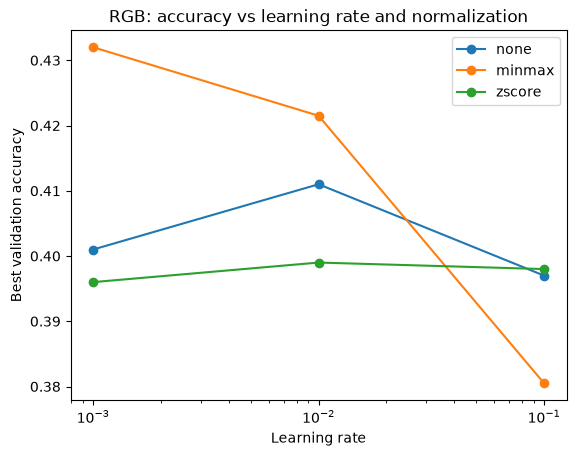

In [24]:
for method in norm_methods:
    accs = [results_rgb[(alpha, method)] for alpha in learning_rates]
    plt.plot(learning_rates, accs, marker='o', label=method)

plt.xscale('log')
plt.xlabel("Learning rate")
plt.ylabel("Best validation accuracy")
plt.title("RGB: accuracy vs learning rate and normalization")
plt.legend()
plt.show()

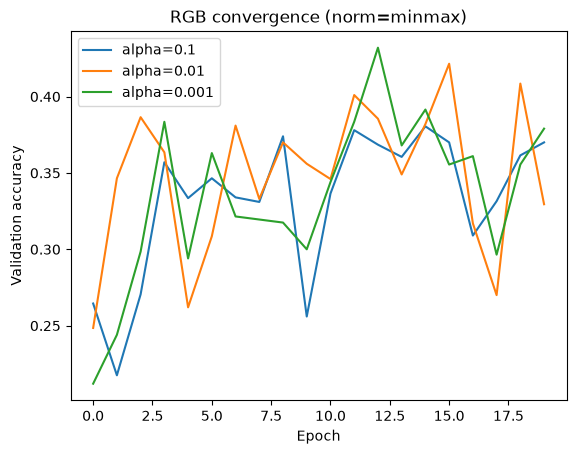

In [25]:
best_method_rgb = "minmax" #(method that did best)

for alpha in learning_rates:
    plt.plot(histories_rgb[(alpha, best_method_rgb)], label=f"alpha={alpha}")

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title(f"RGB convergence (norm={best_method_rgb})")
plt.legend()
plt.show()

In [26]:
# TASK 5
#refiting normalisation using train stats + applying to train/valid/test

def get_norm_stats(X_train, method):
    """Works out whatever stats are needed for the chosen normalisation
    method, calculated only from the training data"""
    if method == "none":
        return {"method": "none"}
    elif method == "minmax":
        return {"method": "minmax"}
    elif method == "zscore":
        return {"method": "zscore", "mean": X_train.mean(), "std": X_train.std()}

def apply_norm(X, stats):
    """ Applies the previously calculated normalisation stats to any
    dataset (train, validation ortest) so they're all scaled the same way"""
    if stats["method"] == "none":
        return X * 255.0
    elif stats["method"] == "minmax":
        return X
    elif stats["method"] == "zscore":
        return (X - stats["mean"]) / stats["std"]

BEST_METHOD = "minmax"
BEST_ALPHA = 0.001

In [27]:
# Final grayscale model
stats_gray = get_norm_stats(X_train_gray, BEST_METHOD)
X_train_final_gray = apply_norm(X_train_gray, stats_gray)
X_valid_final_gray = apply_norm(X_valid_gray, stats_gray)
X_test_final_gray  = apply_norm(X_test_gray, stats_gray)

np.random.seed(1234)
final_gray_model = MultiClassPerceptron(n_inputs=X_train_final_gray.shape[1], n_classes=10, alpha=BEST_ALPHA)
for epoch in range(20):
    indices = np.random.permutation(len(X_train_final_gray))
    for i in indices:
        final_gray_model.apply_learning_rule(X_train_final_gray[i], y_train_gray[i])


In [28]:
# Final RGB model
stats_rgb = get_norm_stats(X_train_rgb, BEST_METHOD)
X_train_final_rgb = apply_norm(X_train_rgb, stats_rgb)
X_valid_final_rgb = apply_norm(X_valid_rgb, stats_rgb)
X_test_final_rgb  = apply_norm(X_test_rgb, stats_rgb)

np.random.seed(1234)
final_rgb_model = MultiClassPerceptron(n_inputs=X_train_final_rgb.shape[1], n_classes=10, alpha=BEST_ALPHA)
for epoch in range(20):
    indices = np.random.permutation(len(X_train_final_rgb))
    for i in indices:
        final_rgb_model.apply_learning_rule(X_train_final_rgb[i], y_train_rgb[i])


In [29]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt

def evaluate_model(model, X, y_true, class_names, set_name):
"""Gets predictions from the model, prints accuracy/precision/recall/F1
    overall and per class, and shows a confusion matrix"""
    y_pred = np.array([model.predict(x) for x in X])

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print(set_name)
    print("Accuracy:", round(accuracy, 2))
    print("Precision:", round(precision, 2))
    print("Recall:", round(recall, 2))
    print("F1:", round(f1, 2))

    precision_c, recall_c, f1_c, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )

    print("\nPer-class results:")
    for i in range(len(class_names)):
        print(class_names[i],
              "Precision:", round(precision_c[i], 2),
              "Recall:", round(recall_c[i], 2),
              "F1:", round(f1_c[i], 2))

    cm = confusion_matrix(y_true, y_pred)

    plt.imshow(cm)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - " + set_name)
    plt.xticks(range(10), class_names, rotation=90)
    plt.yticks(range(10), class_names)
    plt.colorbar()
    plt.show()

Grayscale Validation
Accuracy: 0.17
Precision: 0.26
Recall: 0.17
F1: 0.14

Per-class results:
bart_simpson Precision: 0.15 Recall: 0.31 F1: 0.21
charles_montgomery_burns Precision: 0.38 Recall: 0.13 F1: 0.19
homer_simpson Precision: 0.37 Recall: 0.12 F1: 0.19
krusty_the_clown Precision: 0.34 Recall: 0.11 F1: 0.17
lisa_simpson Precision: 0.22 Recall: 0.07 F1: 0.11
marge_simpson Precision: 0.11 Recall: 0.01 F1: 0.01
milhouse_van_houten Precision: 0.33 Recall: 0.01 F1: 0.02
moe_szyslak Precision: 0.12 Recall: 0.72 F1: 0.21
ned_flanders Precision: 0.31 Recall: 0.1 F1: 0.15
principal_skinner Precision: 0.29 Recall: 0.14 F1: 0.19


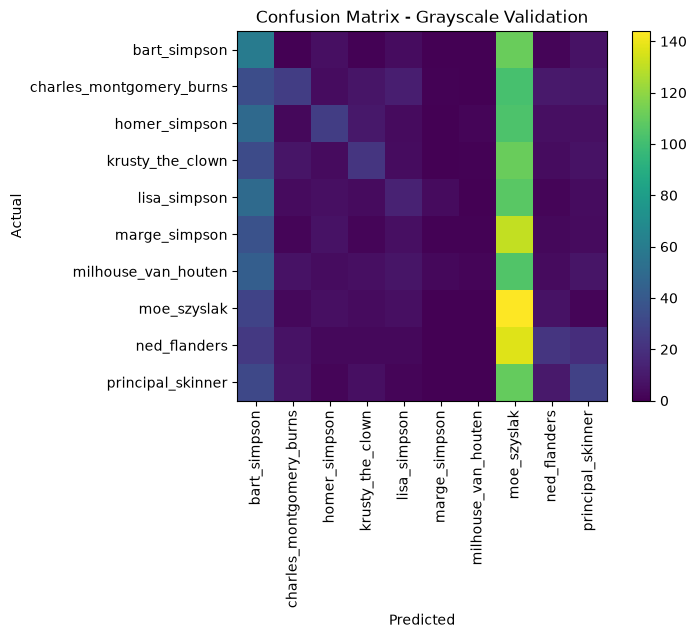

In [30]:
# Grayscale-validation
evaluate_model(final_gray_model, X_valid_final_gray, y_valid_gray, class_names, "Grayscale Validation")

RGB Validation
Accuracy: 0.38
Precision: 0.47
Recall: 0.38
F1: 0.36

Per-class results:
bart_simpson Precision: 0.51 Recall: 0.1 F1: 0.17
charles_montgomery_burns Precision: 0.33 Recall: 0.33 F1: 0.33
homer_simpson Precision: 0.34 Recall: 0.47 F1: 0.39
krusty_the_clown Precision: 0.71 Recall: 0.37 F1: 0.48
lisa_simpson Precision: 0.39 Recall: 0.33 F1: 0.36
marge_simpson Precision: 0.62 Recall: 0.68 F1: 0.65
milhouse_van_houten Precision: 0.6 Recall: 0.16 F1: 0.26
moe_szyslak Precision: 0.27 Recall: 0.63 F1: 0.38
ned_flanders Precision: 0.63 Recall: 0.11 F1: 0.19
principal_skinner Precision: 0.29 Recall: 0.61 F1: 0.39


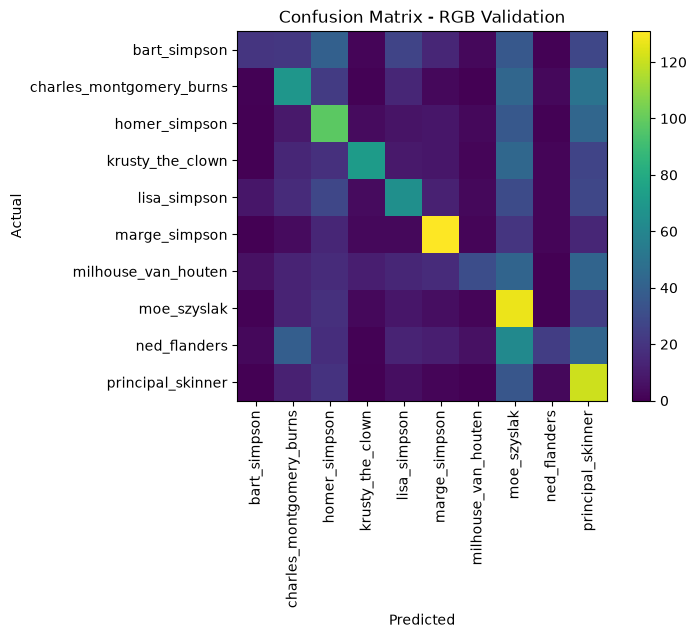

In [31]:
# RGB-validation
evaluate_model(final_rgb_model, X_valid_final_rgb, y_valid_rgb, class_names, "RGB Validation")

Grayscale Test
Accuracy: 0.16
Precision: 0.27
Recall: 0.16
F1: 0.14

Per-class results:
bart_simpson Precision: 0.17 Recall: 0.33 F1: 0.23
charles_montgomery_burns Precision: 0.29 Recall: 0.1 F1: 0.15
homer_simpson Precision: 0.28 Recall: 0.1 F1: 0.15
krusty_the_clown Precision: 0.25 Recall: 0.08 F1: 0.13
lisa_simpson Precision: 0.21 Recall: 0.08 F1: 0.12
marge_simpson Precision: 0.12 Recall: 0.0 F1: 0.01
milhouse_van_houten Precision: 0.71 Recall: 0.05 F1: 0.09
moe_szyslak Precision: 0.12 Recall: 0.67 F1: 0.2
ned_flanders Precision: 0.23 Recall: 0.07 F1: 0.11
principal_skinner Precision: 0.34 Recall: 0.15 F1: 0.21


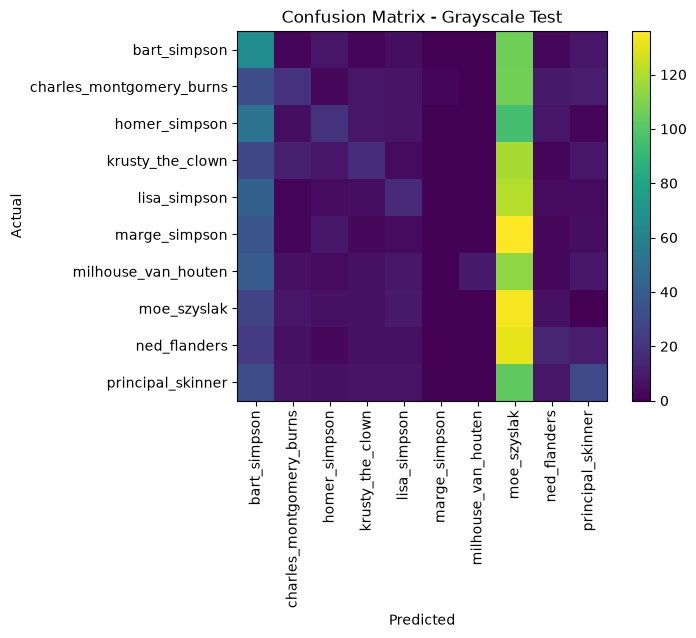

In [32]:
# Grayscale-test
evaluate_model(final_gray_model, X_test_final_gray, y_test_gray, class_names, "Grayscale Test")

RGB Test
Accuracy: 0.38
Precision: 0.47
Recall: 0.38
F1: 0.37

Per-class results:
bart_simpson Precision: 0.5 Recall: 0.12 F1: 0.19
charles_montgomery_burns Precision: 0.32 Recall: 0.34 F1: 0.33
homer_simpson Precision: 0.33 Recall: 0.48 F1: 0.39
krusty_the_clown Precision: 0.71 Recall: 0.38 F1: 0.5
lisa_simpson Precision: 0.39 Recall: 0.32 F1: 0.35
marge_simpson Precision: 0.62 Recall: 0.7 F1: 0.66
milhouse_van_houten Precision: 0.71 Recall: 0.22 F1: 0.34
moe_szyslak Precision: 0.25 Recall: 0.52 F1: 0.34
ned_flanders Precision: 0.56 Recall: 0.11 F1: 0.18
principal_skinner Precision: 0.28 Recall: 0.6 F1: 0.38


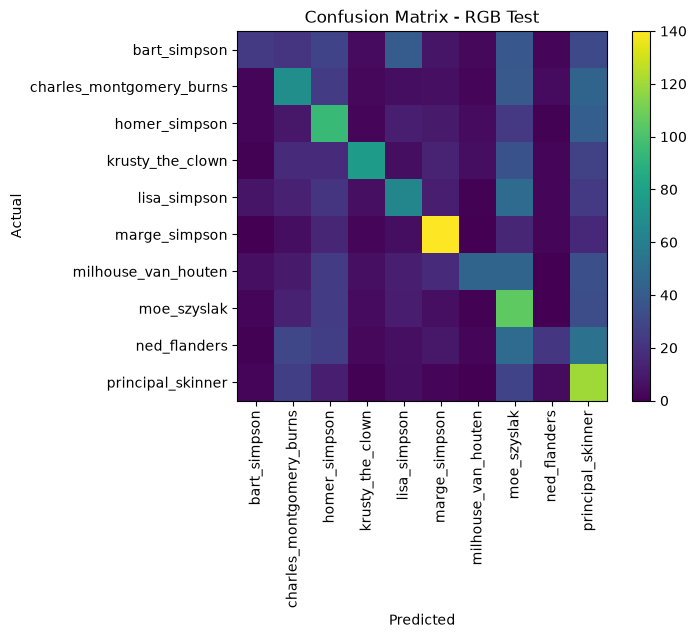

In [33]:
# RGB-test
evaluate_model(final_rgb_model, X_test_final_rgb, y_test_rgb, class_names, "RGB Test")

In [34]:
# TASK 7- dataa augmentation
sample_dir = os.path.join(DATASET_PATH, "rgb", "train", class_names[0])
sample_file = os.listdir(sample_dir)[0]
sample_image = Image.open(os.path.join(sample_dir, sample_file)).convert("RGB")

img_height, img_width = np.array(sample_image).shape[:2]

In [35]:
def unflatten_images(X, height, width):
    """Undoes the flattening/scaling from Task 1 so the images are back
    in their original (height, width, 3) pixel array form"""
    X = (X * 255).astype(np.uint8)
    return X.reshape(X.shape[0], height, width, 3)


X_train_rgb_raw = unflatten_images(X_train_rgb, img_height, img_width)

In [36]:
def brightness_jitter(img):
    """Randomly scales all the pixel values in image to make it
    brighter or darker, without changing were anything is positioned"""
    b = np.random.uniform(0.7, 1.3)
    return np.clip(img.astype(float) * b, 0, 255).astype(np.uint8)

In [37]:
def random_rotation(img):
    """Rotates an image by random small angle using Pillow"""
    angle = np.random.uniform(-15, 15)
    return np.array(Image.fromarray(img).rotate(angle))

In [38]:
def augment_dataset(X, y, method):

    """Creates 1 augmented copy of every image in X using the chosen
    method, keeping same label as the original for each copy"""

    X_aug = []

    for img in X:
        if method == "brightness":
            X_aug.append(brightness_jitter(img))
        elif method == "rotation":
            X_aug.append(random_rotation(img))

    return np.array(X_aug), y.copy()

def build_training_set(X, y, method):
    """Builds final training set for a given condition: either just
    the originals or originals plus augmented copies flattened and
    normalised same way as Task 1"""

    if method == "none":
        X_combined = X
        y_combined = y

    else:
        X_aug, y_aug = augment_dataset(X, y, method)
        X_combined = np.concatenate([X, X_aug])
        y_combined = np.concatenate([y, y_aug])

    X_combined = X_combined.reshape(X_combined.shape[0], -1)
    X_combined = X_combined.astype(float) / 255.0

    return X_combined, y_combined

In [39]:
def train_and_test(X_train, y_train, X_test, y_test, alpha, epochs, seed):
    """Trains a fresh multi-class perceptron on the given training set
    and returns its accuracy on the test set"""
    np.random.seed(seed)

    model = MultiClassPerceptron(
        n_inputs=X_train.shape[1],
        n_classes=10,
        alpha=alpha
    )

    for epoch in range(epochs):
        indices = np.random.permutation(len(X_train))

        for i in indices:
            model.apply_learning_rule(X_train[i], y_train[i])

    correct = 0

    for i in range(len(X_test)):
        if model.predict(X_test[i]) == y_test[i]:
            correct += 1

    return correct / len(X_test)

In [40]:
# Running experiment-> 3 conditions x 5 seeds each, using RGB's best+ task 4 settins
 
BEST_RGB_ALPHA = 0.001
EPOCHS = 20
SEEDS = [0, 1, 2, 3, 4]
CONDITIONS = ["none", "brightness", "rotation"]
 
augmentation_results = {}
 
for condition in CONDITIONS:
 
    test_accuracies = []
 
    for seed in SEEDS:
        np.random.seed(seed)
 
        X_train_combined, y_train_combined = build_training_set(
            X_train_rgb_raw, y_train_rgb, condition
        )
 
        acc = train_and_test(
            X_train_combined, y_train_combined,
            X_test_final_rgb, y_test_rgb,
            alpha=BEST_RGB_ALPHA,
            epochs=EPOCHS,
            seed=seed
        )
 
        test_accuracies.append(acc)
        print(f"Condition={condition}, seed={seed} -> test accuracy: {acc:.3f}")
 
    mean_acc = np.mean(test_accuracies)
    std_acc = np.std(test_accuracies)
    augmentation_results[condition] = (mean_acc, std_acc)
 
    print(f"\n{condition}: mean={mean_acc:.3f}, std={std_acc:.3f}\n")
 

Condition=none, seed=0 -> test accuracy: 0.410
Condition=none, seed=1 -> test accuracy: 0.358
Condition=none, seed=2 -> test accuracy: 0.374
Condition=none, seed=3 -> test accuracy: 0.330
Condition=none, seed=4 -> test accuracy: 0.399

none: mean=0.374, std=0.029

Condition=brightness, seed=0 -> test accuracy: 0.336
Condition=brightness, seed=1 -> test accuracy: 0.337
Condition=brightness, seed=2 -> test accuracy: 0.418
Condition=brightness, seed=3 -> test accuracy: 0.398
Condition=brightness, seed=4 -> test accuracy: 0.332

brightness: mean=0.364, std=0.037

Condition=rotation, seed=0 -> test accuracy: 0.281
Condition=rotation, seed=1 -> test accuracy: 0.385
Condition=rotation, seed=2 -> test accuracy: 0.383
Condition=rotation, seed=3 -> test accuracy: 0.321
Condition=rotation, seed=4 -> test accuracy: 0.346

rotation: mean=0.343, std=0.039



In [41]:
#The summarytable
print("Condition       Mean test accuracy   Std dev")
for condition in CONDITIONS:
    mean_acc, std_acc = augmentation_results[condition]
    print(f"{condition:<15} {mean_acc:.3f}                {std_acc:.3f}")
 

Condition       Mean test accuracy   Std dev
none            0.374                0.029
brightness      0.364                0.037
rotation        0.343                0.039


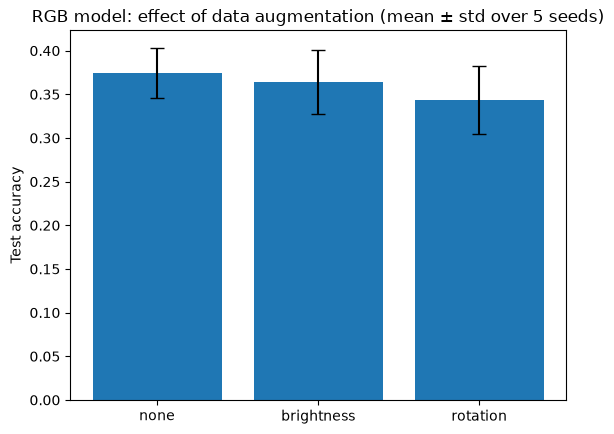

In [42]:
import matplotlib.pyplot as plt
 
means = [augmentation_results[c][0] for c in CONDITIONS]
stds = [augmentation_results[c][1] for c in CONDITIONS]
 
plt.bar(CONDITIONS, means, yerr=stds, capsize=5)
plt.ylabel("Test accuracy")
plt.title("RGB model: effect of data augmentation (mean \u00b1 std over 5 seeds)")
plt.show()